# Iris Flower Classification with Machine Learning

## Aim
To analyze the Iris dataset using Data Science and Machine Learning techniques including visualization, EDA, and classification.

## Import Required Libraries

## Dataset Used

The notebook automatically loads the Iris dataset directly using an online CSV source.
No manual upload is required.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset

In [2]:
# Load Iris dataset directly from online CSV source

url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

iris_df = pd.read_csv(url)

# Rename columns for consistency
iris_df = iris_df.rename(columns={
    'sepal_length': 'sepal length (cm)',
    'sepal_width': 'sepal width (cm)',
    'petal_length': 'petal length (cm)',
    'petal_width': 'petal width (cm)',
    'species': 'species'
})

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Create DataFrame

In [3]:
# Drop Id column if present
if 'Id' in iris_df.columns:
    iris_df = iris_df.drop('Id', axis=1)

# Rename Species column
iris_df = iris_df.rename(columns={
    'Species': 'species'
})

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Dataset Information

In [4]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### Observation
- Dataset contains 150 rows and 5 columns.
- No null values are present.

## Check Missing Values

In [5]:
iris_df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


## Statistical Summary

In [6]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Check Duplicate Values

In [7]:
iris_df.duplicated().sum()

np.int64(3)

## Remove Duplicate Values

In [8]:
iris_df = iris_df.drop_duplicates()

## Count of Each Species

In [9]:
iris_df['species'].value_counts()

,count
species,
versicolor,50
virginica,49
setosa,48


# Exploratory Data Analysis (EDA)

## Pairplot Visualization

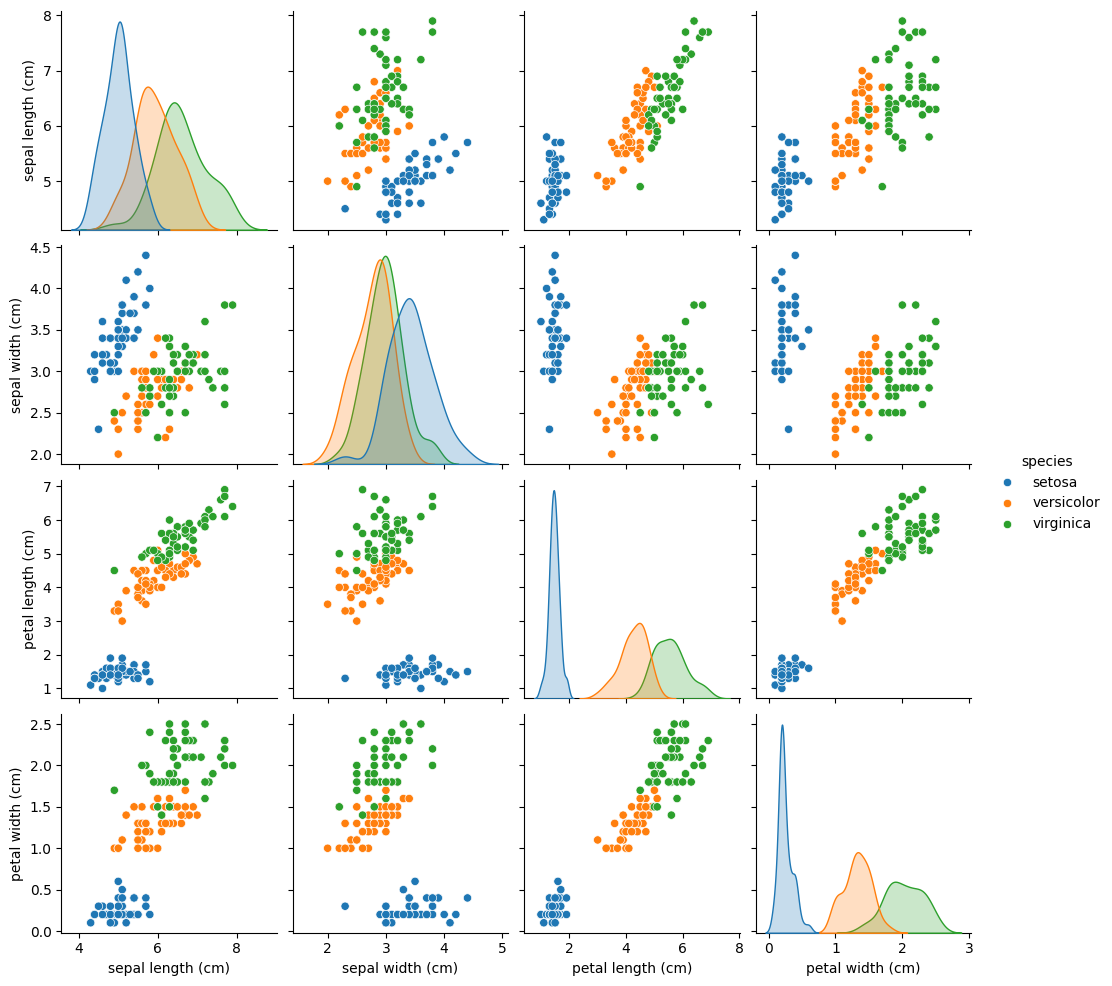

In [10]:
sns.pairplot(iris_df, hue='species')
plt.show()

### Observation
- Setosa species is clearly separable from others.

## Histogram

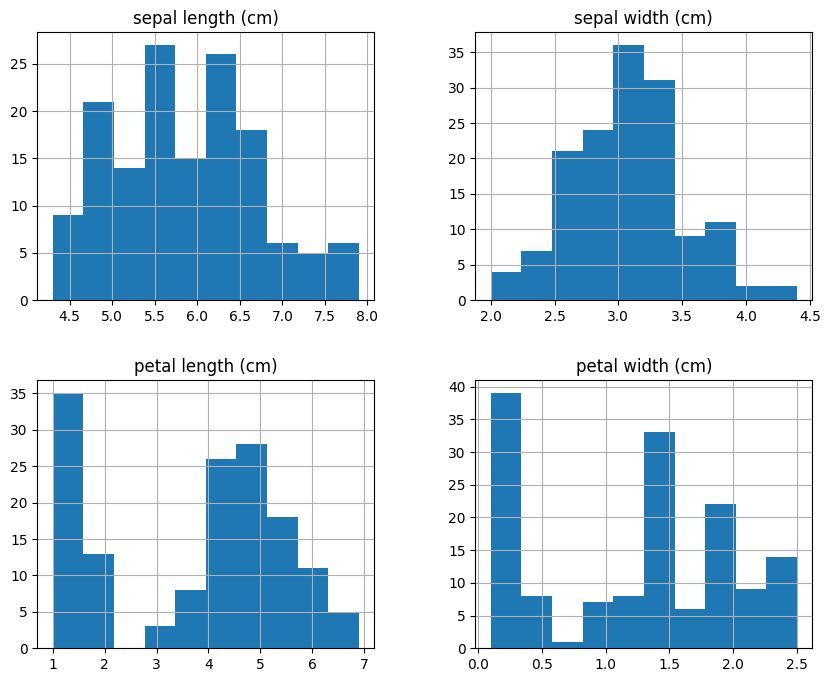

In [11]:
iris_df.hist(figsize=(10,8))
plt.show()

## Scatter Plot

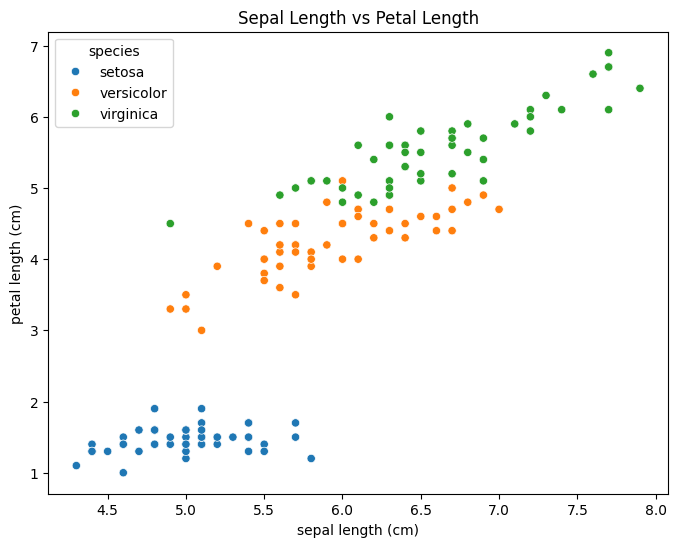

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',
    data=iris_df
)

plt.title('Sepal Length vs Petal Length')
plt.show()

## Boxplot

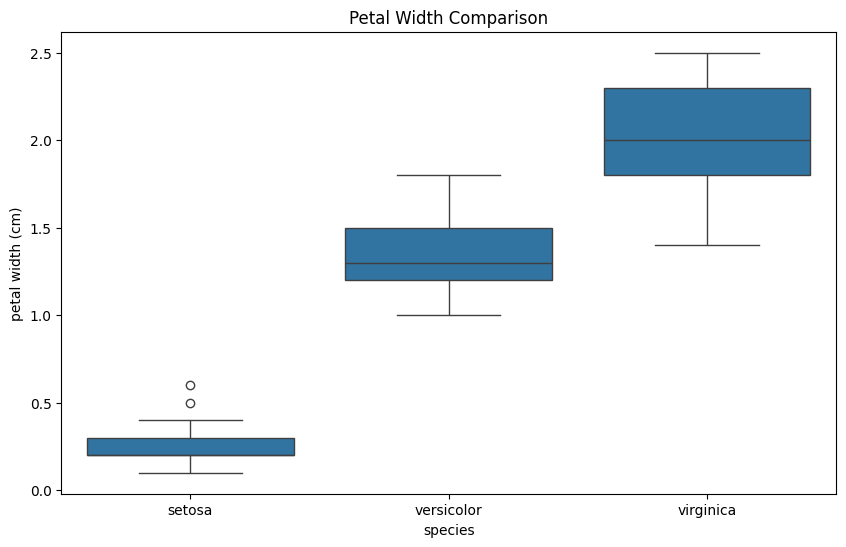

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='species',
    y='petal width (cm)',
    data=iris_df
)

plt.title('Petal Width Comparison')
plt.show()

## Correlation Matrix

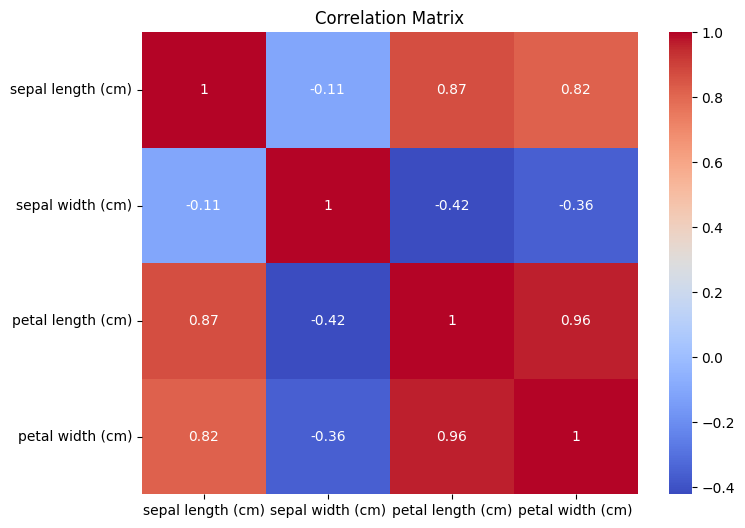

In [14]:
correlation = iris_df.drop('species', axis=1).corr()

plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

### Observation
- Petal length and petal width are highly correlated.

# Machine Learning

## Prepare Features and Target

In [15]:
X = iris_df.drop('species', axis=1)
y = iris_df['species']

## Split Dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Model

In [17]:
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

## Make Predictions

In [18]:
y_pred = model.predict(X_test)

## Accuracy Score

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


## Confusion Matrix

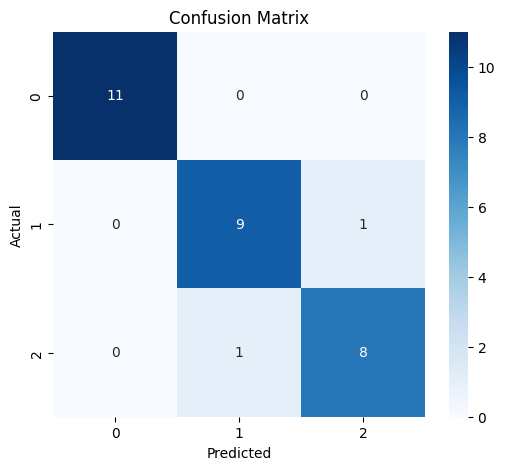

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

## Classification Report

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.90      0.90      0.90        10
   virginica       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Predict New Flower

In [22]:
sample = pd.DataFrame({
    'sepal length (cm)': [5.1],
    'sepal width (cm)': [3.5],
    'petal length (cm)': [1.4],
    'petal width (cm)': [0.2]
})

prediction = model.predict(sample)

print("Predicted Class:", prediction[0])

Predicted Class: setosa


## Conclusion
- Iris dataset was analyzed successfully.
- Various visualization techniques were applied.
- KNN classification model achieved high accuracy.
- The model successfully predicted flower species.